# Exploration

In [ ]:
# save the trained Stage 2 model
model2.save(GEOCELL_MODEL)
print("Stage 2 saved to", GEOCELL_MODEL)


Stage 2 saved to /content/drive/MyDrive/Colab Notebooks/Advanced Analytics/data_assign2/checkpoints/geocell_weights.keras


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 6) Stage 3: absolute‐coords head
# ─────────────────────────────────────────────────────────────────────────────
# a) attach linear coords head
abs_out     = Dense(2, activation="linear", name="coords_abs")(feat)
model3_abs  = Model(inputs=c_model.input, outputs=abs_out)
for L in model3_abs.layers:
    if L.name!="coords_abs": L.trainable=False

# b) compile & fit on (lat,lon)
model3_abs.compile(optimizer=Adam(1e-4), loss="mse", metrics=["mae"])
model3_abs.fit(
    train_ds3_abs,
    validation_data=val_ds3_abs,
    epochs=10,
    callbacks=[
      tf.keras.callbacks.ModelCheckpoint(
          COORDS_MODEL, save_best_only=True, monitor="val_mae", mode="min"),
      tf.keras.callbacks.ReduceLROnPlateau(
          monitor="val_mae", factor=0.2, patience=2, mode="min"),
      tf.keras.callbacks.EarlyStopping(
          monitor="val_mae", patience=5, restore_best_weights=True, mode="min")
    ]
)
print("✅ Stage 3 saved to", COORDS_MODEL)

# ─────────────────────────────────────────────────────────────────────────────
# 7) Full inference + evaluation
# ─────────────────────────────────────────────────────────────────────────────
g_model  = load_model(GEOCELL_MODEL)
m3_abs   = load_model(COORDS_MODEL)

inf_ds = tf.data.Dataset.from_tensor_slices(df_val["filepath"].values)
inf_ds = inf_ds.map(lambda p: preprocess_input(
             tf.image.resize(tf.image.decode_jpeg(tf.io.read_file(p),3),
                             [IMG_SIZE,IMG_SIZE])
           )).batch(BATCH)

# 1) country
cp     = c_model.predict(inf_ds, verbose=1)
c_pred = np.argmax(cp, axis=1)

# 2) geocell (masked)
gp       = g_model.predict(inf_ds, verbose=1)
dfc      = df_cent.loc[le_g.classes_]
cell2c   = dfc["country_lbl"].values
final_cell = []
for i, ci in enumerate(c_pred):
    valid     = (cell2c == ci)
    logits    = np.where(valid, gp[i], -1e9)
    probs     = tf.nn.softmax(logits).numpy()
    final_cell.append(np.argmax(probs))
final_cell = np.array(final_cell)

# 3) absolute coords
pred_abs    = m3_abs.predict(inf_ds, verbose=1)   # (N,2)
# end‐to‐end = pred_abs
final_coords = pred_abs

# 4) Haversine error
true_coords = df_val[["lat","lon"]].values
errors = [haversine(tuple(t), tuple(p)) for t,p in zip(true_coords, final_coords)]
print("→ Mean Haversine error [km]:", np.mean(errors))

# 5) Confusion matrix for country
cm = confusion_matrix(true_c, c_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le_c.classes_)
fig,ax = plt.subplots(1,1,figsize=(8,8))
disp.plot(ax=ax, cmap="viridis", xticks_rotation=45)
plt.show()

In [ ]:
model2 = load_model(GEOCELL_MODEL)

def compute_geocell_accuracy(ds, model, cell2country):
    y_true, y_pred = [], []
    for imgs, labels in ds:
        # unpack
        country_lbl = tf.cast(labels[:,0], tf.int32).numpy()
        geocell_lbl = tf.cast(labels[:,1], tf.int32).numpy()

        # get raw logits from the geocell head
        _, geo_logits = model.predict(imgs, verbose=0)

        for i in range(len(geo_logits)):
            # mask out all cells not in this sample's country
            mask          = (cell2country == country_lbl[i])
            masked_logits = np.where(mask, geo_logits[i], -1e9)
            pred_cell     = np.argmax(masked_logits)
            y_pred.append(pred_cell)

        y_true.extend(geocell_lbl.tolist())

    return accuracy_score(y_true, y_pred)

# 3) Compute both accuracies
train_acc = compute_geocell_accuracy(train_ds2, model2, gc_country_lbl)
val_acc   = compute_geocell_accuracy(val_ds2,   model2, gc_country_lbl)

print(f"geocell_accuracy:     {train_acc:.4f}")
print(f"val_geocell_accuracy: {val_acc:.4f}")

geocell_accuracy:     0.3485
val_geocell_accuracy: 0.3485


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import load_model

# 1) (Re)load your masked-geocell model if needed
# model2 = load_model(GEOCELL_MODEL)

y_true, y_pred = [], []
for imgs, labels in val_ds2:
    # unpack ground-truth
    country_lbl = tf.cast(labels[:,0], tf.int32).numpy()
    geocell_lbl = tf.cast(labels[:,1], tf.int32).numpy()

    # get logits from the geocell head
    _, geo_logits = model2.predict(imgs, verbose=0)

    # apply country mask + argmax per sample
    for i in range(len(geo_logits)):
        mask = (gc_country_lbl == country_lbl[i])        # valid cells for this country
        masked_logits = np.where(mask, geo_logits[i], -1e9)
        y_pred.append(np.argmax(masked_logits))

    # accumulate true labels
    y_true.extend(geocell_lbl.tolist())

# 2) Build a DataFrame with human-readable names
df_map = pd.DataFrame({
    "true_geocell":  [le_g.classes_[i] for i in y_true],
    "pred_geocell":  [le_g.classes_[i] for i in y_pred],
})

# 3) Inspect the first few mappings
df_map.head(20)


,true_geocell,pred_geocell
0,argentina_0,argentina_0
1,argentina_0,argentina_0
2,argentina_3,argentina_0
3,argentina_0,argentina_0
4,argentina_0,argentina_0
5,argentina_5,argentina_0
6,argentina_0,argentina_0
7,argentina_0,argentina_0
8,argentina_4,argentina_0
9,argentina_4,argentina_0


In [ ]:
df_map.to_csv("/content/drive/MyDrive/Colab Notebooks/Advanced Analytics/data_assign2/geocell_predictions_vs_actual.csv", index=False)

In [ ]:
from geopy.distance import geodesic
import pandas as pd

# 1) Map each geocell label to its (lat,lon) tuple
df_map['true_coord'] = df_map['true_geocell'].map(
    lambda cid: (df_cent.loc[cid,'centroid_lat'], df_cent.loc[cid,'centroid_lon'])
)
df_map['pred_coord'] = df_map['pred_geocell'].map(
    lambda cid: (df_cent.loc[cid,'centroid_lat'], df_cent.loc[cid,'centroid_lon'])
)

# 2) Compute the geodesic distance between true & predicted centroids
df_map['error_km'] = df_map.apply(
    lambda row: geodesic(row['true_coord'], row['pred_coord']).kilometers,
    axis=1
)

# 3) Inspect the first few rows
print(df_map[['true_geocell','pred_geocell','error_km']].head())

  true_geocell pred_geocell   error_km
0  argentina_0  argentina_0    0.00000
1  argentina_0  argentina_0    0.00000
2  argentina_3  argentina_0  596.06197
3  argentina_0  argentina_0    0.00000
4  argentina_0  argentina_0    0.00000


In [ ]:
import folium
import numpy as np

# 1) Build a quick lookup of centroids by geocell_id
#    (df_cent was your centroids DataFrame, indexed by geocell_id)
centroid_map = df_cent[['centroid_lat','centroid_lon']].to_dict('index')

# 2) Add true/predicted coords to your df_map
df_map['true_coord'] = df_map['true_geocell'].map(lambda cid: tuple(centroid_map[cid].values()))
df_map['pred_coord'] = df_map['pred_geocell'].map(lambda cid: tuple(centroid_map[cid].values()))

# 3) (Optional) sample a subset so the map isn’t overloaded
df_plot = df_map.sample(min(200, len(df_map)), random_state=42).reset_index(drop=True)

# 4) Center the map on the mean of the true coords
mean_lat = np.mean([c[0] for c in df_plot['true_coord']])
mean_lon = np.mean([c[1] for c in df_plot['true_coord']])
m = folium.Map(location=[mean_lat, mean_lon], zoom_start=3)

# 5) Draw a line for each sample
for _, row in df_plot.iterrows():
    tlat, tlon = row['true_coord']
    plat, plon = row['pred_coord']
    color = 'green' if row['true_geocell']==row['pred_geocell'] else 'red'
    folium.PolyLine(
        locations=[(tlat,tlon),(plat,plon)],
        color=color,
        weight=2,
        opacity=0.6
    ).add_to(m)

# 6) Show the map
m


In [ ]:
import pandas as pd

# 1) Build a lookup: geocell_id → country name
country_of_cell = df_cent['country'].to_dict()  # df_cent indexed by geocell_id

# 2) Annotate df_map with the true country for each row
df_map['true_country'] = df_map['true_geocell'].map(country_of_cell)

# 3) Compute, for each country, the normalized count of predicted cells
dist = (
    df_map
      .groupby('true_country')['pred_geocell']
      .value_counts(normalize=True)
      .rename('pct')
      .reset_index()
)

# 4) Show the top‐3 most frequent preds per country
top3 = (
    dist
      .groupby('true_country')
      .apply(lambda d: d.nlargest(3, 'pct')[['pred_geocell','pct']])
)

print(top3)


                  pred_geocell       pct
true_country                            
argentina    0     argentina_0  1.000000
austria      1       austria_6  0.943750
             2       austria_2  0.025000
             3       austria_3  0.025000
canada       5        canada_4  1.000000
chile        6         chile_0  1.000000
france       7        france_2  0.546875
             8        france_5  0.421875
             9        france_3  0.023438
iceland      11      iceland_1  1.000000
italy        12        italy_3  1.000000
japan        13        japan_0  1.000000
new_zealand  14  new_zealand_1  1.000000
norway       15       norway_0  0.956522
             16       norway_4  0.043478
peru         17         peru_2  1.000000
switzerland  18  switzerland_4  0.956284
             19  switzerland_3  0.027322
             20  switzerland_5  0.010929


<ipython-input-25-a8195ac1736f>:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: d.nlargest(3, 'pct')[['pred_geocell','pct']])


Refine

In [ ]:
# New multi-task hierarchical geocell training script
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.metrics import Mean, SparseCategoricalAccuracy
from sklearn.preprocessing import LabelEncoder
from collections import Counter
from tqdm import tqdm

# ─────────────────────────────────────────────────────────────────────────────
# 0) Constants & paths
# ─────────────────────────────────────────────────────────────────────────────
IMG_SIZE     = 224
BATCH        = 32
EPOCHS       = 20
LR           = 1e-5
LAMBDA_GEO   = 1.0  # weight for geocell loss

TRAIN_CSV     = "/content/drive/MyDrive/Colab Notebooks/Advanced Analytics/data_assign2/geocell_train.csv"
VAL_CSV       = "/content/drive/MyDrive/Colab Notebooks/Advanced Analytics/data_assign2/geocell_val.csv"
CENT_CSV      = "/content/drive/MyDrive/Colab Notebooks/Advanced Analytics/data_assign2/geocell_centroids.csv"
COUNTRY_MODEL = "/content/drive/MyDrive/Colab Notebooks/Advanced Analytics/data_assign2/checkpoints/best_result.keras"
OUTPUT_MODEL_MODEL = "/content/drive/MyDrive/Colab Notebooks/Advanced Analytics/data_assign2/checkpoints/br_geocell_full_mixup.keras"

# ─────────────────────────────────────────────────────────────────────────────
# 1) Load & normalize paths
# ─────────────────────────────────────────────────────────────────────────────
df_cent = pd.read_csv(CENT_CSV).set_index("geocell_id")
df_train = pd.read_csv(TRAIN_CSV)
df_val   = pd.read_csv(VAL_CSV)

for df in (df_train, df_val):
    df["filepath"] = (
        df["filepath"]
          .str.replace("\\\\", "/", regex=False)
          .str.replace(r"^final_dataset/train",
                       "/content/drive/MyDrive/Colab Notebooks/Advanced Analytics/data_assign2/train_small",
                       regex=True)
          .str.replace(r"^final_dataset/validation",
                       "/content/drive/MyDrive/Colab Notebooks/Advanced Analytics/data_assign2/validation_small",
                       regex=True)
    )

df_train["filepath"] = df_train["filepath"].str.replace("\\\\", "/", regex=True)
df_val  ["filepath"] = df_val ["filepath"].str.replace("\\\\", "/", regex=True)

le_c = LabelEncoder().fit(df_train["country"])
le_g = LabelEncoder().fit(df_train["geocell_id"])

df_train["country_lbl"] = le_c.transform(df_train["country"])
df_val  ["country_lbl"] = le_c.transform(df_val["country"])
df_train["geocell_lbl"] = le_g.transform(df_train["geocell_id"])
df_val  ["geocell_lbl"] = le_g.transform(df_val["geocell_id"])

num_countries = len(le_c.classes_)
num_geocells  = len(le_g.classes_)

# build mask_per_country and class_weights
# mask_per_country[country_idx, geocell_idx] = True if geocell belongs to country
cent_country_lbl = le_c.transform(df_cent["country"])  # assumes lowercases match
mask_per_country = tf.constant(
    np.stack([cent_country_lbl == i for i in range(num_countries)]),
    dtype=tf.bool
)
# class weights for geocell
counts = Counter(df_train["geocell_lbl"])
total  = sum(counts.values())
class_weights = tf.constant([
    total/(num_geocells * counts[i]) for i in range(num_geocells)
], dtype=tf.float32)

# ─────────────────────────────────────────────────────────────────────────────
# 2) Data pipelines
# ─────────────────────────────────────────────────────────────────────────────
def load_and_preprocess(path, c_lbl, g_lbl):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.keras.applications.resnet50.preprocess_input(img)
    return img, c_lbl, g_lbl

# train dataset
train_ds = (
    tf.data.Dataset.from_tensor_slices((
        df_train.filepath.values,
        df_train.country_lbl.values.astype(np.int32),
        df_train.geocell_lbl.values.astype(np.int32)
    ))
    .shuffle(len(df_train))
    .map(load_and_preprocess, tf.data.AUTOTUNE)
    .batch(BATCH)
    .prefetch(tf.data.AUTOTUNE)
)

# validation dataset
val_ds = (
    tf.data.Dataset.from_tensor_slices((
        df_val.filepath.values,
        df_val.country_lbl.values.astype(np.int32),
        df_val.geocell_lbl.values.astype(np.int32)
    ))
    .map(load_and_preprocess, tf.data.AUTOTUNE)
    .batch(BATCH)
    .prefetch(tf.data.AUTOTUNE)
)

# ─────────────────────────────────────────────────────────────────────────────
# 3) Build two-head model
# ─────────────────────────────────────────────────────────────────────────────
# load pretrained country model backbone
base = load_model(COUNTRY_MODEL)
feat = base.layers[-2].output
inp  = base.input

# two new heads
country_logits = Dense(num_countries, activation='softmax', name='country')(feat)
geocell_logits = Dense(num_geocells, name='geocell_raw')(feat)

model = Model(inp, [country_logits, geocell_logits])

# freeze all backbone layers
for layer in base.layers:
    layer.trainable = False

# ─────────────────────────────────────────────────────────────────────────────
# 4) Loss functions & optimizer
# ─────────────────────────────────────────────────────────────────────────────
country_loss_fn = CategoricalCrossentropy()
# hierarchical geocell loss
@tf.function
def geocell_hier_loss(y_true_geo, geo_logits, c_lbl):
    # y_true_geo: one-hot geocell labels  [B, G]
    # geo_logits: raw logits                 [B, G]
    mask   = tf.gather(mask_per_country, c_lbl)            # [B, G]
    neg_inf= tf.constant(-1e9, dtype=geo_logits.dtype)
    masked = tf.where(mask, geo_logits, neg_inf)           # [B, G]
    probs  = tf.nn.softmax(masked, axis=1)                 # [B, G]
    per_ce = -tf.reduce_sum(y_true_geo * tf.math.log(probs + 1e-7), axis=1)
    weights = tf.gather(class_weights, tf.argmax(y_true_geo, axis=1))
    return tf.reduce_mean(per_ce * weights)

optimizer = Adam(LR)

# ─────────────────────────────────────────────────────────────────────────────
# 5) Training & validation steps
# ─────────────────────────────────────────────────────────────────────────────
NEG_INF = tf.constant(-1e9, dtype=tf.float32)

@tf.function
def train_step(imgs, c_lbl, g_lbl):
    # one-hot labels
    y_c = tf.one_hot(c_lbl, num_countries)
    y_g = tf.one_hot(g_lbl, num_geocells)
    with tf.GradientTape() as tape:
        c_logits, g_logits = model(imgs, training=True)
        # country loss
        l_c = country_loss_fn(y_c, c_logits)
        # geocell hierarchical loss
        l_g = geocell_hier_loss(y_g, g_logits, c_lbl)
        loss = l_c + LAMBDA_GEO * l_g
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss, c_logits, g_logits

@tf.function
def val_step(imgs, c_lbl, g_lbl):
    c_logits, g_logits = model(imgs, training=False)
    y_g = tf.one_hot(g_lbl, num_geocells)
    l_c = country_loss_fn(tf.one_hot(c_lbl, num_countries), c_logits)
    l_g = geocell_hier_loss(y_g, g_logits, c_lbl)
    loss = l_c + LAMBDA_GEO * l_g
    return loss, c_logits, g_logits

# ─────────────────────────────────────────────────────────────────────────────
# 6) Training loop
# ─────────────────────────────────────────────────────────────────────────────
# metrics
train_loss = Mean(); train_acc_c = SparseCategoricalAccuracy(); train_acc_geo = SparseCategoricalAccuracy()
val_loss   = Mean(); val_acc_c = SparseCategoricalAccuracy(); val_acc_geo = SparseCategoricalAccuracy()

for epoch in range(1, EPOCHS+1):
    # reset metrics
    train_loss.reset_state();  train_acc_c.reset_state();  train_acc_geo.reset_state()
    val_loss.reset_state();    val_acc_c.reset_state();    val_acc_geo.reset_state()

    # training
    for imgs, c_lbl, g_lbl in tqdm(train_ds, desc=f"Epoch {epoch} [train]"):
        loss, c_log, g_log = train_step(imgs, c_lbl, g_lbl)
        train_loss.update_state(loss)
        train_acc_c.update_state(c_lbl, c_log)
        # oracle geocell (true-country mask)
        mask   = tf.gather(mask_per_country, c_lbl)
        masked = tf.where(mask, g_log, NEG_INF)
        train_acc_geo.update_state(g_lbl, masked)

    # validation
    for imgs, c_lbl, g_lbl in tqdm(val_ds, desc=f"Epoch {epoch} [val]"):
        loss, c_log, g_log = val_step(imgs, c_lbl, g_lbl)
        val_loss.update_state(loss)
        val_acc_c.update_state(c_lbl, c_log)
        mask   = tf.gather(mask_per_country, c_lbl)
        masked = tf.where(mask, g_log, NEG_INF)
        val_acc_geo.update_state(g_lbl, masked)

    # logging
    print(f"Epoch {epoch}: ")
    print(f"  train loss={train_loss.result():.4f}  country acc={train_acc_c.result():.2%}  geocell acc={train_acc_geo.result():.2%}")
    print(f"  val   loss={val_loss.result():.4f}  country acc={val_acc_c.result():.2%}  geocell acc={val_acc_geo.result():.2%}")

# ─────────────────────────────────────────────────────────────────────────────
# 7) Save model
# ─────────────────────────────────────────────────────────────────────────────
model.save(OUTPUT_MODEL)
print("Multi-task hierarchical model saved.")


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 438 variables whereas the saved optimizer has 442 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
Epoch 1 [val]: 100%|██████████| 50/50 [00:07<00:00,  6.84it/s]


Epoch 1: 
  train loss=9.9660  country acc=12.50%  geocell acc=13.44%
  val   loss=5.5703  country acc=22.20%  geocell acc=13.28%


Epoch 2 [val]: 100%|██████████| 50/50 [00:01<00:00, 26.12it/s]


Epoch 2: 
  train loss=9.4946  country acc=14.30%  geocell acc=14.24%
  val   loss=5.2934  country acc=24.86%  geocell acc=13.22%


Epoch 3 [val]: 100%|██████████| 50/50 [00:02<00:00, 24.54it/s]


...

Epoch 19 [val]: 100%|██████████| 50/50 [00:01<00:00, 25.13it/s]


Epoch 19: 
  train loss=5.5342  country acc=49.45%  geocell acc=15.37%
  val   loss=2.8641  country acc=77.55%  geocell acc=15.31%


Epoch 20 [val]: 100%|██████████| 50/50 [00:01<00:00, 26.60it/s]

Epoch 20: 
  train loss=5.4635  country acc=52.04%  geocell acc=14.81%
  val   loss=2.8116  country acc=79.32%  geocell acc=15.75%


NameError: name 'OUTPUT_MODEL' is not defined

In [ ]:
model.save("/content/drive/MyDrive/Colab Notebooks/Advanced Analytics/data_assign2/checkpoints/br_geocell_full_mixup.keras")
print("Multi-task hierarchical model saved.")

Multi-task hierarchical model saved.


In [3]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models    import load_model, Model
from tensorflow.keras.layers    import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics   import CategoricalAccuracy
from sklearn.preprocessing      import LabelEncoder
from collections                import Counter
from tqdm                       import tqdm
import math

# ─────────────────────────────────────────────────────────────────────────────
# 0) Constants & file paths
# ─────────────────────────────────────────────────────────────────────────────
IMG_SIZE       = 224
BATCH_SIZE     = 32
EPOCHS         = 30
LR             = 1e-4
THRESHOLD      = 150  # minimum combined sample

TRAIN_CSV     = "/content/drive/MyDrive/Colab Notebooks/Advanced Analytics/data_assign2/geocell_train.csv"
VAL_CSV       = "/content/drive/MyDrive/Colab Notebooks/Advanced Analytics/data_assign2/geocell_val.csv"
CENT_CSV      = "/content/drive/MyDrive/Colab Notebooks/Advanced Analytics/data_assign2/geocell_centroids.csv"
COUNTRY_MODEL = "/content/drive/MyDrive/Colab Notebooks/Advanced Analytics/data_assign2/checkpoints/best_result.keras"
OUTPUT_MODEL  = "/content/drive/MyDrive/Colab Notebooks/Advanced Analytics/data_assign2/checkpoints/geocell_min_model.keras"

# ─────────────────────────────────────────────────────────────────────────────
# 1) Load & normalize paths
# ─────────────────────────────────────────────────────────────────────────────
df_cent = pd.read_csv(CENT_CSV).set_index("geocell_id")
df_train = pd.read_csv(TRAIN_CSV)
df_val   = pd.read_csv(VAL_CSV)

for df in (df_train, df_val):
    df["filepath"] = (
        df["filepath"]
          .str.replace("\\\\", "/", regex=False)
          .str.replace(r"^final_dataset/train",
                       "/content/drive/MyDrive/Colab Notebooks/Advanced Analytics/data_assign2/train_small",
                       regex=True)
          .str.replace(r"^final_dataset/validation",
                       "/content/drive/MyDrive/Colab Notebooks/Advanced Analytics/data_assign2/validation_small",
                       regex=True)
    )

df_train["filepath"] = df_train["filepath"].str.replace("\\\\", "/", regex=True)
df_val  ["filepath"] = df_val ["filepath"].str.replace("\\\\", "/", regex=True)

le_c = LabelEncoder().fit(df_train["country"])
# initial geocell id encoder (for merging map)
le_g_orig = LabelEncoder().fit(df_train["geocell_id"])

df_train["country_lbl"] = le_c.transform(df_train["country"])
df_val  ["country_lbl"] = le_c.transform(df_val["country"])

df_train["geocell_lbl_orig"] = le_g_orig.transform(df_train["geocell_id"])
df_val  ["geocell_lbl_orig"] = le_g_orig.transform(df_val["geocell_id"])

# Automatically detect centroid columns (two numeric cols)
num_cols = df_cent.select_dtypes(include=[np.number]).columns.tolist()
if len(num_cols) < 2:
    raise ValueError(f"Expected at least 2 numeric centroid columns, found {num_cols}")
lat_col, lon_col = num_cols[0], num_cols[1]

# ─────────────────────────────────────────────────────────────────────────────
# 2) Merge rare geocells by nearest neighbor
# ─────────────────────────────────────────────────────────────────────────────
counts = Counter(df_train['geocell_id'])
rare   = {gc for gc,c in counts.items() if c < THRESHOLD}
common = [gc for gc,c in counts.items() if c >= THRESHOLD]

# haversine distance function
def haversine(lat1, lon1, lat2, lon2):
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlambda/2)**2
    return 2 * 6371 * math.atan2(math.sqrt(a), math.sqrt(1-a))

# Build merge map
gc_map = {}
for r in rare:
    lat0, lon0 = df_cent.loc[r, [lat_col, lon_col]]
    sorted_common = sorted(
        common,
        key=lambda c: haversine(lat0, lon0, df_cent.loc[c, lat_col], df_cent.loc[c, lon_col])
    )
    target = next((c for c in sorted_common if counts[r] + counts[c] >= THRESHOLD), sorted_common[0])
    gc_map[r] = target

# apply mapping
df_train['geocell_merge'] = df_train['geocell_id'].map(lambda g: gc_map.get(g, g))
df_val['geocell_merge']   = df_val['geocell_id'].map(lambda g: gc_map.get(g, g))

# ─────────────────────────────────────────────────────────────────────────────
# 3) Encode final labels
# ─────────────────────────────────────────────────────────────────────────────
le_g = LabelEncoder().fit(df_train['geocell_merge'])
for df in (df_train, df_val):
    df['geocell_lbl'] = le_g.transform(df['geocell_merge'])

num_countries = len(le_c.classes_)
num_geocells  = len(le_g.classes_)

# rebuild mask_per_country
cent_country_lbl = le_c.transform(df_cent['country'])
mask_per_country = tf.constant(
    np.stack([cent_country_lbl == i for i in range(num_countries)]), dtype=tf.bool
)

# ─────────────────────────────────────────────────────────────────────────────
# 4) Data pipelines
# ─────────────────────────────────────────────────────────────────────────────
def preprocess(path, lbl):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.keras.applications.resnet50.preprocess_input(img)
    return img, lbl

train_ds = (
    tf.data.Dataset.from_tensor_slices((
        df_train.filepath.values,
        tf.one_hot(df_train.geocell_lbl.values, depth=num_geocells)
    ))
    .shuffle(len(df_train))
    .map(preprocess, tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((
        df_val.filepath.values,
        tf.one_hot(df_val.geocell_lbl.values, depth=num_geocells)
    ))
    .map(preprocess, tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# ─────────────────────────────────────────────────────────────────────────────
# 5) Load & freeze stage1 country model
# ─────────────────────────────────────────────────────────────────────────────
stage1 = load_model(COUNTRY_MODEL)
for layer in stage1.layers:
    layer.trainable = False

# ─────────────────────────────────────────────────────────────────────────────
# 6) Build geocell head
# ─────────────────────────────────────────────────────────────────────────────
feat   = stage1.layers[-2].output
gc_out = Dense(num_geocells, activation='softmax', name='geocell')(feat)
geocell_model = Model(stage1.input, gc_out)

# ─────────────────────────────────────────────────────────────────────────────
# 7) Focal loss definition
# ─────────────────────────────────────────────────────────────────────────────
def focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1-1e-7)
        ce     = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=1)
        p_t    = tf.reduce_sum(y_true * y_pred, axis=1)
        weight = alpha * tf.pow(1.0 - p_t, gamma)
        return tf.reduce_mean(weight * ce)
    return loss_fn

geocell_model.compile(
    optimizer=Adam(LR),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=[CategoricalAccuracy(name='geocell_acc')]
)

# ─────────────────────────────────────────────────────────────────────────────
# 8) Train geocell head
# ─────────────────────────────────────────────────────────────────────────────
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(OUTPUT_MODEL, monitor='val_geocell_acc', save_best_only=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_geocell_acc', factor=0.5, patience=2),
    tf.keras.callbacks.EarlyStopping(monitor='val_geocell_acc', patience=3, restore_best_weights=True)
]

geocell_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

# ─────────────────────────────────────────────────────────────────────────────
# 9) Save final model
# ─────────────────────────────────────────────────────────────────────────────
geocell_model.save(OUTPUT_MODEL)
print("Geocell head trained with merging & focal loss saved to", OUTPUT_MODEL)


Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 438 variables whereas the saved optimizer has 442 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


375/375 ━━━━━━━━━━━━━━━━━━━━ 880s 2s/step - geocell_acc: 0.0290 - loss: 1.7925 - val_geocell_acc: 0.1505 - val_loss: 0.7252 - learning_rate: 1.0000e-04
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - geocell_acc: 0.1233 - loss: 1.1712 - val_geocell_acc: 0.3744 - val_loss: 0.4560 - learning_rate: 1.0000e-04
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - geocell_acc: 0.2382 - loss: 0.8352 - val_geocell_acc: 0.4269 - val_loss: 0.3635 - learning_rate: 1.0000e-04
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - geocell_acc: 0.3128 - loss: 0.6701 - val_geocell_acc: 0.4466 - val_loss: 0.3232 - learning_rate: 1.0000e-04
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 44ms/step - geocell_acc: 0.3662 - loss: 0.5653 - val_geocell_acc: 0.4592 - val_loss: 0.3034 - learning_rate: 1.0000e-04
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - geocell_acc: 0.3914 - loss: 0.5182 - val_geocell_acc: 0.4611 - val_loss: 0.2867 - learning_rate: 1.0000e-04
Epoch 7/30
375/375 ━━━━━━━━━

In [5]:
# 2) Imports
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.preprocessing import LabelEncoder
from collections import Counter
import math

# 3) Paths
TRAIN_CSV     = "/content/drive/MyDrive/Colab Notebooks/Advanced Analytics/data_assign2/geocell_train.csv"
VAL_CSV       = "/content/drive/MyDrive/Colab Notebooks/Advanced Analytics/data_assign2/geocell_val.csv"
CENT_CSV      = "/content/drive/MyDrive/Colab Notebooks/Advanced Analytics/data_assign2/geocell_centroids.csv"
OUTPUT_MODEL  = "/content/drive/MyDrive/Colab Notebooks/Advanced Analytics/data_assign2/checkpoints/geocell_min_model.keras"

# 4) Reload data
df_cent = pd.read_csv(CENT_CSV).set_index("geocell_id")
df_train = pd.read_csv(TRAIN_CSV)
df_val   = pd.read_csv(VAL_CSV)

for df in (df_train, df_val):
    df["filepath"] = (
        df["filepath"]
          .str.replace("\\\\", "/", regex=False)
          .str.replace(r"^final_dataset/train",
                       "/content/drive/MyDrive/Colab Notebooks/Advanced Analytics/data_assign2/train_small",
                       regex=True)
          .str.replace(r"^final_dataset/validation",
                       "/content/drive/MyDrive/Colab Notebooks/Advanced Analytics/data_assign2/validation_small",
                       regex=True)
    )

df_train["filepath"] = df_train["filepath"].str.replace("\\\\", "/", regex=True)
df_val  ["filepath"] = df_val ["filepath"].str.replace("\\\\", "/", regex=True)

le_c = LabelEncoder().fit(df_train["country"])
# initial geocell id encoder (for merging map)
le_g_orig = LabelEncoder().fit(df_train["geocell_id"])

df_train["country_lbl"] = le_c.transform(df_train["country"])
df_val  ["country_lbl"] = le_c.transform(df_val["country"])

df_train["geocell_lbl_orig"] = le_g_orig.transform(df_train["geocell_id"])
df_val  ["geocell_lbl_orig"] = le_g_orig.transform(df_val["geocell_id"])

# Automatically detect centroid columns (two numeric cols)
num_cols = df_cent.select_dtypes(include=[np.number]).columns.tolist()
if len(num_cols) < 2:
    raise ValueError(f"Expected at least 2 numeric centroid columns, found {num_cols}")
lat_col, lon_col = num_cols[0], num_cols[1]

# 5) Rebuild the rare→neighbor map exactly as in training:
THRESHOLD = 150
counts = Counter(df_train['geocell_id'])
rare   = {gc for gc,c in counts.items() if c < THRESHOLD}
common = [gc for gc,c in counts.items() if c >= THRESHOLD]

# detect which centroid columns to use:
num_cols = df_cent.select_dtypes(include=[np.number]).columns.tolist()
lat_col, lon_col = num_cols[:2]

def haversine(lat1, lon1, lat2, lon2):
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlambda/2)**2
    return 2 * 6371 * math.atan2(math.sqrt(a), math.sqrt(1-a))

gc_map = {}
for r in rare:
    lat0, lon0 = df_cent.loc[r, [lat_col, lon_col]]
    sorted_common = sorted(common,
        key=lambda c: haversine(lat0, lon0,
                                df_cent.loc[c, lat_col],
                                df_cent.loc[c, lon_col]))
    # pick first where combined >= threshold
    target = next((c for c in sorted_common if counts[r] + counts[c] >= THRESHOLD),
                  sorted_common[0])
    gc_map[r] = target

# apply it
df_train['geocell_merge'] = df_train['geocell_id'].map(lambda g: gc_map.get(g, g))
df_val  ['geocell_merge'] = df_val  ['geocell_id'].map(lambda g: gc_map.get(g, g))

# 6) Re‐fit LabelEncoder on merged labels
le_g = LabelEncoder().fit(df_train['geocell_merge'])
df_val['true_geocell'] = le_g.transform(df_val['geocell_merge'])

# 7) Load the trained geocell head
geocell_model = load_model(OUTPUT_MODEL, compile=False)

# 8) Build X_val and predict
from tensorflow.keras.applications.resnet50 import preprocess_input
def load_img(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [224,224])
    return preprocess_input(img)

X_val = np.stack([ load_img(p).numpy() for p in df_val['filepath'].values ])
y_pred = geocell_model.predict(X_val, batch_size=32).argmax(axis=1)

# 9) Build df_map & do grouping
df_map = pd.DataFrame({
    'true_geocell': df_val['geocell_merge'].values,
    'pred_geocell': le_g.inverse_transform(y_pred),
})
country_of_cell = df_cent['country'].to_dict()
df_map['true_country'] = df_map['true_geocell'].map(country_of_cell)

dist = (
    df_map
      .groupby('true_country')['pred_geocell']
      .value_counts(normalize=True)
      .rename('pct')
      .reset_index()
)
top6 = (
    dist
      .groupby('true_country')
      .apply(lambda d: d.nlargest(6, 'pct')[['pred_geocell','pct']])
)
print(top6)


50/50 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step
                   pred_geocell       pct
true_country                             
argentina    0      argentina_0  0.589286
             1          chile_0  0.348214
             2      argentina_5  0.053571
             3        iceland_1  0.008929
austria      4        austria_6  0.465909
...                         ...       ...
switzerland  105  switzerland_4  0.197605
             106        japan_6  0.029940
             107        italy_3  0.017964
             108        japan_3  0.017964
             109      austria_0  0.011976

[65 rows x 2 columns]


<ipython-input-5-c3e82d787238>:121: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: d.nlargest(6, 'pct')[['pred_geocell','pct']])


In [6]:
import folium
import numpy as np

# 1) Build a quick lookup of centroids by geocell_id
#    (df_cent was your centroids DataFrame, indexed by geocell_id)
centroid_map = df_cent[['centroid_lat','centroid_lon']].to_dict('index')

# 2) Add true/predicted coords to your df_map
df_map['true_coord'] = df_map['true_geocell'].map(lambda cid: tuple(centroid_map[cid].values()))
df_map['pred_coord'] = df_map['pred_geocell'].map(lambda cid: tuple(centroid_map[cid].values()))

# 3) (Optional) sample a subset so the map isn’t overloaded
df_plot = df_map.sample(min(200, len(df_map)), random_state=42).reset_index(drop=True)

# 4) Center the map on the mean of the true coords
mean_lat = np.mean([c[0] for c in df_plot['true_coord']])
mean_lon = np.mean([c[1] for c in df_plot['true_coord']])
m = folium.Map(location=[mean_lat, mean_lon], zoom_start=3)

# 5) Draw a line for each sample
for _, row in df_plot.iterrows():
    tlat, tlon = row['true_coord']
    plat, plon = row['pred_coord']
    color = 'green' if row['true_geocell']==row['pred_geocell'] else 'red'
    folium.PolyLine(
        locations=[(tlat,tlon),(plat,plon)],
        color=color,
        weight=2,
        opacity=0.6
    ).add_to(m)

# 6) Show the map
m

In [4]:
# Hierarchical Geocell Training with Merging, Focal Loss, and Masked Custom Loop

# 1) Mount Drive (if on Colab)
from google.colab import drive
drive.mount('/content/drive')

# 2) Imports
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models    import load_model, Model
from tensorflow.keras.layers    import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics   import Mean, SparseCategoricalAccuracy
from sklearn.preprocessing      import LabelEncoder
from collections                import Counter
import math

# 3) Constants & paths
IMG_SIZE      = 224
BATCH_SIZE    = 32
EPOCHS        = 30
LR            = 1e-4
THRESHOLD     = 150  # min combined samples for merging

TRAIN_CSV     = "/content/drive/MyDrive/Colab Notebooks/Advanced Analytics/data_assign2/geocell_train.csv"
VAL_CSV       = "/content/drive/MyDrive/Colab Notebooks/Advanced Analytics/data_assign2/geocell_val.csv"
CENT_CSV      = "/content/drive/MyDrive/Colab Notebooks/Advanced Analytics/data_assign2/geocell_centroids.csv"
COUNTRY_MODEL = "/content/drive/MyDrive/Colab Notebooks/Advanced Analytics/data_assign2/checkpoints/best_result.keras"
OUTPUT_MODEL  = "/content/drive/MyDrive/Colab Notebooks/Advanced Analytics/data_assign2/checkpoints/geocell_hierarchical.keras"

# 4) Load & normalize filepaths
df_cent = pd.read_csv(CENT_CSV).set_index("geocell_id")
df_train = pd.read_csv(TRAIN_CSV)
df_val   = pd.read_csv(VAL_CSV)

for df in (df_train, df_val):
    df["filepath"] = (
        df["filepath"]
          .str.replace("\\\\", "/", regex=False)
          .str.replace(r"^final_dataset/train",
                       "/content/drive/MyDrive/Colab Notebooks/Advanced Analytics/data_assign2/train_small",
                       regex=True)
          .str.replace(r"^final_dataset/validation",
                       "/content/drive/MyDrive/Colab Notebooks/Advanced Analytics/data_assign2/validation_small",
                       regex=True)
    )

df_train["filepath"] = df_train["filepath"].str.replace("\\\\", "/", regex=True)
df_val  ["filepath"] = df_val ["filepath"].str.replace("\\\\", "/", regex=True)

# 5) Build rare→neighbor merge map
le_c      = LabelEncoder().fit(df_train["country"])
le_g_orig = LabelEncoder().fit(df_train["geocell_id"])
df_train["country_lbl"]      = le_c.transform(df_train["country"])
df_val  ["country_lbl"]      = le_c.transform(df_val["country"])
df_train["geocell_lbl_orig"] = le_g_orig.transform(df_train["geocell_id"])
df_val  ["geocell_lbl_orig"] = le_g_orig.transform(df_val["geocell_id"])

counts = Counter(df_train["geocell_id"])
rare   = {gc for gc,c in counts.items() if c < THRESHOLD}
common = [gc for gc,c in counts.items() if c >= THRESHOLD]

num_cols = df_cent.select_dtypes(include=[np.number]).columns.tolist()
lat_col, lon_col = num_cols[:2]

def haversine(lat1, lon1, lat2, lon2):
    φ1, φ2 = math.radians(lat1), math.radians(lat2)
    dφ     = math.radians(lat2 - lat1)
    dλ     = math.radians(lon2 - lon1)
    a = math.sin(dφ/2)**2 + math.cos(φ1)*math.cos(φ2)*math.sin(dλ/2)**2
    return 2 * 6371 * math.atan2(math.sqrt(a), math.sqrt(1-a))

gc_map = {}
for r in rare:
    lat0, lon0 = df_cent.loc[r, [lat_col, lon_col]]
    sorted_common = sorted(common,
        key=lambda c: haversine(lat0, lon0,
                                 df_cent.loc[c, lat_col],
                                 df_cent.loc[c, lon_col]))
    target = next((c for c in sorted_common if counts[r] + counts[c] >= THRESHOLD),
                  sorted_common[0])
    gc_map[r] = target

df_train["geocell_merge"] = df_train["geocell_id"].map(lambda g: gc_map.get(g, g))
df_val  ["geocell_merge"] = df_val  ["geocell_id"].map(lambda g: gc_map.get(g, g))

# 6) Final encodings
le_g = LabelEncoder().fit(df_train["geocell_merge"])
df_train["geocell_lbl"] = le_g.transform(df_train["geocell_merge"])
df_val  ["geocell_lbl"] = le_g.transform(df_val["geocell_merge"])

num_countries = len(le_c.classes_)
num_geocells  = len(le_g.classes_)

# 7) Build mask_per_country for merged classes
gc2c = [ le_c.transform([df_cent.loc[g, "country"]])[0] for g in le_g.classes_ ]
mask_per_country = tf.constant(
    np.stack([np.array(gc2c)==i for i in range(num_countries)]),
    dtype=tf.bool
)

# 8) Precompute distance matrix
coords = df_cent.loc[le_g.classes_, [lat_col, lon_col]].values
_dist = np.zeros((num_geocells, num_geocells), dtype=np.float32)
for i in range(num_geocells):
    for j in range(num_geocells):
        _dist[i,j] = haversine(coords[i,0], coords[i,1],
                               coords[j,0], coords[j,1])
distance_matrix = tf.constant(_dist)
TAU = 200.0  # smoothing temperature

# 9) Load & freeze country model, build geocell head
stage1 = load_model(COUNTRY_MODEL)
for layer in stage1.layers:
    layer.trainable = False

feat   = stage1.layers[-2].output
gc_raw = Dense(num_geocells, name="geocell_raw")(feat)
model2 = Model(stage1.input, gc_raw)
opt    = Adam(LR)

# 10) Data pipelines
def make_ds(df, shuffle=True):
    paths = df["filepath"].values
    c_lbl = df["country_lbl"].values.astype(np.int32)
    g_lbl = df["geocell_lbl"].values.astype(np.int32)
    ds = tf.data.Dataset.from_tensor_slices((paths, c_lbl, g_lbl))
    if shuffle: ds = ds.shuffle(len(df))
    def load(p,c,g):
        img = tf.io.read_file(p)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [IMG_SIZE,IMG_SIZE])
        img = tf.keras.applications.resnet50.preprocess_input(img)
        return img, c, g
    return ds.map(load, tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(df_train, shuffle=True)
val_ds   = make_ds(df_val,   shuffle=False)

# 11) Distance‐smoothed train/val steps
@tf.function
def train_step(imgs, c_lbl, g_lbl):
    with tf.GradientTape() as tape:
        g_logits = model2(imgs, training=True)
        mask     = tf.gather(mask_per_country, c_lbl)
        g_masked = tf.where(mask, g_logits, tf.constant(-1e9, dtype=g_logits.dtype))
        g_probs  = tf.nn.softmax(g_masked, axis=1)

        dists      = tf.gather(distance_matrix, g_lbl)
        dists_mask = tf.where(mask, dists, tf.constant(1e6, dtype=dists.dtype))
        y_smooth   = tf.nn.softmax(-dists_mask/TAU, axis=1)

        loss = -tf.reduce_mean(tf.reduce_sum(y_smooth * tf.math.log(g_probs+1e-7), axis=1))

    grads = tape.gradient(loss, model2.trainable_variables)
    opt.apply_gradients(zip(grads, model2.trainable_variables))
    return loss, g_probs

@tf.function
def val_step(imgs, c_lbl, g_lbl):
    g_logits = model2(imgs, training=False)
    mask     = tf.gather(mask_per_country, c_lbl)
    g_masked = tf.where(mask, g_logits, tf.constant(-1e-9, dtype=g_logits.dtype))
    g_probs  = tf.nn.softmax(g_masked, axis=1)

    dists      = tf.gather(distance_matrix, g_lbl)
    dists_mask = tf.where(mask, dists, tf.constant(1e6, dtype=dists.dtype))
    y_smooth   = tf.nn.softmax(-dists_mask/TAU, axis=1)
    loss       = -tf.reduce_mean(tf.reduce_sum(y_smooth * tf.math.log(g_probs+1e-7), axis=1))

    return loss, g_probs

# 12) Prediction helper
def predict_geocell(imgs):
    c_logits = stage1(imgs, training=False)
    c_pred   = tf.argmax(c_logits, axis=1)
    g_logits = model2(imgs, training=False)
    mask     = tf.gather(mask_per_country, c_pred)
    g_masked = tf.where(mask, g_logits, tf.constant(-1e9, dtype=g_logits.dtype))
    return tf.nn.softmax(g_masked, axis=1)

# 13) Training loop
for epoch in range(1, EPOCHS+1):
    train_loss = Mean(); train_acc = SparseCategoricalAccuracy()
    val_loss   = Mean(); val_acc   = SparseCategoricalAccuracy()

    for imgs,c_lbl,g_lbl in train_ds:
        loss, g_probs = train_step(imgs, c_lbl, g_lbl)
        preds = tf.argmax(g_probs, axis=1)
        train_loss.update_state(loss)
        train_acc.update_state(g_lbl, preds)

    for imgs,c_lbl,g_lbl in val_ds:
        loss, g_probs = val_step(imgs, c_lbl, g_lbl)
        preds = tf.argmax(g_probs, axis=1)
        val_loss.update_state(loss)
        val_acc.update_state(g_lbl, preds)

    print(f"Epoch {epoch:02d}: "
          f"train_loss={train_loss.result():.4f} "
          f"train_acc={train_acc.result():.2%}   "
          f"val_loss={val_loss.result():.4f} "
          f"val_acc={val_acc.result():.2%}")

    if epoch == 1:
        # Top-6 within true country
        all_true, all_pred = [], []
        for imgs,_,g_lbl in val_ds:
            p = tf.argmax(predict_geocell(imgs), axis=1).numpy()
            all_pred.append(p); all_true.append(g_lbl.numpy())
        y_true = np.concatenate(all_true); y_pred = np.concatenate(all_pred)

        df_map = pd.DataFrame({
            "true_geocell": le_g.inverse_transform(y_true),
            "pred_geocell": le_g.inverse_transform(y_pred),
        })
        df_map["true_country"] = df_map["true_geocell"].map(df_cent["country"].to_dict())
        df_map["pred_country"] = df_map["pred_geocell"].map(df_cent["country"].to_dict())

        df_same = df_map[df_map.true_country == df_map.pred_country]
        dist_same = (df_same
                      .groupby("true_country")["pred_geocell"]
                      .value_counts(normalize=True)
                      .rename("pct").reset_index())
        top6_same = (dist_same
                     .groupby("true_country")
                     .apply(lambda d: d.nlargest(6, "pct")[["pred_geocell","pct"]]))
        print("\nTop-6 within true country (epoch 1):")
        print(top6_same)

# 14) Save
model2.save(OUTPUT_MODEL)
print("Saved hierarchical geocell head to", OUTPUT_MODEL)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 438 variables whereas the saved optimizer has 442 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 01: train_loss=2.1033 train_acc=3.25%   val_loss=3.0078 val_acc=5.12%


<ipython-input-4-03e0f428d205>:229: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: d.nlargest(6, "pct")[["pred_geocell","pct"]]))



Top-6 within true country (epoch 1):
                  pred_geocell       pct
true_country                            
argentina    0     argentina_5  0.743590
             1     argentina_0  0.256410
austria      2       austria_0  0.503876
             3       austria_5  0.457364
             4       austria_6  0.038760
canada       5        canada_4  0.507246
             6        canada_3  0.492754
chile        7         chile_0  1.000000
france       8        france_3  0.551282
             9        france_0  0.243590
             10       france_5  0.153846
             11       france_2  0.051282
iceland      12      iceland_1  1.000000
italy        13        italy_3  0.752941
             14        italy_2  0.176471
             15        italy_0  0.070588
japan        16        japan_0  0.809859
             17        japan_3  0.147887
             18        japan_6  0.042254
new_zealand  19  new_zealand_2  0.991667
             20  new_zealand_1  0.008333
norway       21    

KeyboardInterrupt: 

# 12 country heads

In [19]:
from tensorflow.keras.models    import Model, load_model
from tensorflow.keras.layers    import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses    import SparseCategoricalCrossentropy
import tensorflow as tf
import pandas as pd
import numpy as np
import os
import math
from collections                import Counter
from sklearn.preprocessing      import LabelEncoder
from tensorflow.keras.applications.resnet50 import preprocess_input

# 0) Common: load & freeze country backbone
stage1   = load_model(COUNTRY_MODEL)
for layer in stage1.layers:
    layer.trainable = False
base_feat = stage1.layers[-2].output

# where to save each head + encoder
OUT_DIR = "/content/drive/MyDrive/Colab Notebooks/Advanced Analytics/data_assign2/checkpointscountry_heads"
os.makedirs(OUT_DIR, exist_ok=True)

# 1) Loop per country
for country in le_c.classes_:
    print(f"\n--- Training head for {country} ---")

    # a) Subset
    df_tr_ctry = df_train[df_train.country == country].copy()
    df_va_ctry = df_val  [df_val.country   == country].copy()
    if len(df_tr_ctry)==0 or len(df_va_ctry)==0:
        continue

    # b)  Merge rare geocells (<150 samples) to nearest neighbor
    counts = Counter(df_tr_ctry["geocell_id"])
    rare   = {g for g,c in counts.items() if c < 150}
    common = [g for g,c in counts.items() if c >= 150]

    # get centroids
    cent = df_cent.loc[list(rare)+common, ['centroid_lat','centroid_lon']]
    def hav(lat1,lon1,lat2,lon2):
        φ1,φ2 = math.radians(lat1), math.radians(lat2)
        dφ    = math.radians(lat2-lat1)
        dλ    = math.radians(lon2-lon1)
        a = math.sin(dφ/2)**2 + math.cos(φ1)*math.cos(φ2)*math.sin(dλ/2)**2
        return 2*6371*math.atan2(math.sqrt(a),math.sqrt(1-a))

    merge_map = {}
    for r in rare:
      lat0, lon0 = cent.loc[r]
      nn = min(common, key=lambda g: hav(
        lat0, lon0,
        cent.loc[g, 'centroid_lat'],
        cent.loc[g, 'centroid_lon']))
      merge_map[r] = nn

# simulate merge on train only (do NOT mutate yet)
    merged_train = df_tr_ctry["geocell_id"].map(lambda g: merge_map.get(g, g))
    unique_after = merged_train.nunique()

    if unique_after >= 2:
    # safe—apply it to both train and val
        print(f"  → merging {len(rare)} rare cells → {unique_after} total classes")
        df_tr_ctry["geocell_id"] = merged_train
        df_va_ctry["geocell_id"] = df_va_ctry["geocell_id"].map(lambda g: merge_map.get(g, g))
    else:
    # skip entirely
        print(f"  → skipping merge (would leave only {unique_after} class)")

# now you can encode & build class weights
    le_g_ctry         = LabelEncoder().fit(df_tr_ctry["geocell_id"])
    df_tr_ctry["g_lbl"] = le_g_ctry.transform(df_tr_ctry["geocell_id"])
    df_va_ctry["g_lbl"] = le_g_ctry.transform(df_va_ctry["geocell_id"])
    n_cells           = len(le_g_ctry.classes_)

    cnts = Counter(df_tr_ctry["g_lbl"])
    total = sum(cnts.values())
    class_weight = {lbl: total/(n_cells*c) for lbl,c in cnts.items()}

    # d) Dataset w/ augmentation
    def make_ds(df, shuffle=True):
        paths  = df["filepath"].values
        lbls   = df["g_lbl"].values.astype(np.int32)
        ds     = tf.data.Dataset.from_tensor_slices((paths,lbls))
        if shuffle: ds = ds.shuffle(len(df))
        def _load(p,l):
            img = tf.io.read_file(p)
            img = tf.image.decode_jpeg(img,3)
            img = tf.image.resize(img,[IMG_SIZE,IMG_SIZE])
            img = tf.image.random_flip_left_right(img)
            img = tf.image.random_brightness(img,0.2)
            img = preprocess_input(img)
            return img, l
        return ds.map(_load, tf.data.AUTOTUNE)\
                 .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    ds_tr = make_ds(df_tr_ctry, shuffle=True)
    ds_va = make_ds(df_va_ctry, shuffle=False)

    # e) Unfreeze last conv block
    for layer in stage1.layers[-10:]:
        layer.trainable = True

    # f) Build & compile head with Dropout
    x    = Dropout(0.5, name=f"dropout_{country}")(base_feat)
    head = Dense(n_cells, activation="softmax", name=f"gc_{country}")(x)
    model_ct = Model(stage1.input, head, name=f"model_{country}")
    model_ct.compile(
        optimizer=Adam(1e-5),
        loss=SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )

    # g) Train
    ckpt = os.path.join(OUT_DIR, f"head_{country}.keras")
    hist = model_ct.fit(
        ds_tr,
        validation_data=ds_va,
        epochs=20,
        class_weight=class_weight,
        callbacks=[
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor="val_accuracy", factor=0.5, patience=2, mode="max"),
            tf.keras.callbacks.EarlyStopping(
                monitor="val_accuracy", patience=6, restore_best_weights=True, mode="max")
        ],
        verbose=1
    )

    # h) Report & save
    ta = hist.history["accuracy"][-1]
    va = hist.history["val_accuracy"][-1]
    print(f"{country}: train={ta:.2%}  val={va:.2%}")

    ckpt       = os.path.join(OUT_DIR, f"head_{country}.keras")
    enc_path   = os.path.join(OUT_DIR, f"le_g_{country}.pkl")
    merge_path = os.path.join(OUT_DIR, f"merge_map_{country}.pkl")

    model_ct.save(ckpt)
    with open(enc_path, "wb") as f:
        pickle.dump(le_g_ctry, f)
    with open(merge_path, "wb") as f:
        pickle.dump(merge_map, f)

    print(f"→ Saved: {ckpt}, {enc_path}, {merge_path}")


--- Training head for argentina ---
  → merging 4 rare cells → 2 total classes
Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 438 variables whereas the saved optimizer has 442 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 390ms/step - accuracy: 0.5330 - loss: 1.7846 - val_accuracy: 0.5618 - val_loss: 0.8148 - learning_rate: 1.0000e-05
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.5088 - loss: 1.7051 - val_accuracy: 0.6067 - val_loss: 0.7488 - learning_rate: 1.0000e-05
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.5469 - loss: 1.4038 - val_accuracy: 0.6517 - val_loss: 0.7202 - learning_rate: 1.0000e-05
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.5571 - loss: 1.3575 - val_accuracy: 0.7303 - val_loss: 0.6972 - learning_rate: 1.0000e-05
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.5748 - loss: 1.2406 - val_accuracy: 0.7528 - val_loss: 0.6735 - learning_rate: 1.0000e-05
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.5635 - loss: 1.1433 - val_accuracy: 0.7416 - val_loss: 0.6642 - learning_rate: 1.0000e-05
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.6080 - loss: 1

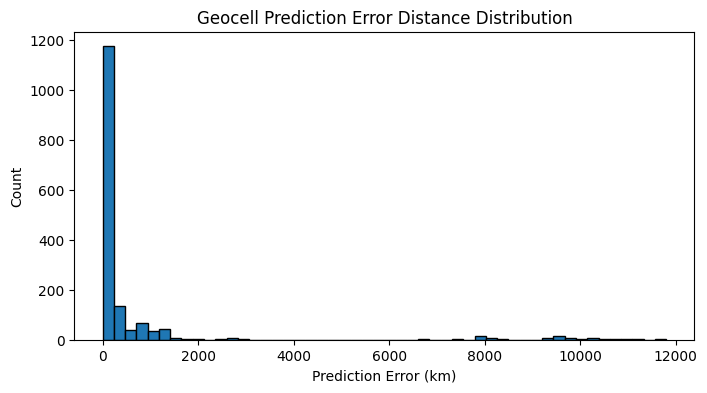


Per‐Country Geocell Accuracy:

              accuracy
true_country          
new_zealand      0.867
argentina        0.775
canada           0.595
switzerland      0.590
peru             0.526
japan            0.420
norway           0.406
italy            0.333
austria          0.288
france           0.211
iceland          0.085
chile            0.067

Geocell Classification Report:

               precision    recall  f1-score   support

  argentina_0       0.80      0.65      0.72        49
  argentina_5       0.58      0.93      0.71        40
    austria_0       0.23      0.31      0.26        49
    austria_5       0.27      0.46      0.34        59
    austria_6       0.17      0.08      0.11        52
     canada_3       0.40      0.56      0.46        41
     canada_4       0.69      0.61      0.65       107
      chile_0       0.77      0.07      0.12       149
      chile_1       0.00      0.00      0.00         0
      chile_2       0.00      0.00      0.00         0
      c

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# 1) Haversine for distance in km
def haversine(p1, p2):
    lat1, lon1 = p1; lat2, lon2 = p2
    φ1, φ2 = np.radians(lat1), np.radians(lat2)
    dφ     = np.radians(lat2 - lat1)
    dλ     = np.radians(lon2 - lon1)
    a = np.sin(dφ/2)**2 + np.cos(φ1)*np.cos(φ2)*np.sin(dλ/2)**2
    return 2 * 6371 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

# 2) Compute error distances
df_map['error_km'] = df_map.apply(
    lambda r: haversine(r['true_coord'], r['pred_coord']),
    axis=1
)

# 3) Plot histogram of errors
plt.figure(figsize=(8,4))
plt.hist(df_map['error_km'], bins=50, edgecolor='black')
plt.xlabel('Prediction Error (km)')
plt.ylabel('Count')
plt.title('Geocell Prediction Error Distance Distribution')
plt.show()

# 4) Per-country accuracy
country_acc = (
    df_map.assign(correct = (df_map['true_geocell']==df_map['pred_geocell']))
          .groupby('true_country')['correct']
          .mean()
          .sort_values(ascending=False)
)
print("\nPer‐Country Geocell Accuracy:\n")
print(country_acc.to_frame('accuracy').round(3))

# 5) Overall geocell classification report
report = classification_report(
    df_map['true_geocell'],
    df_map['pred_geocell'],
    zero_division=0
)
print("\nGeocell Classification Report:\n")
print(report)


# Regression

In [34]:
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import pickle

# 1) Load all merge_maps into a dict (if you haven’t already)
merge_maps = {}
for country in le_c.classes_:
    path = os.path.join(HEADS_DIR, f"merge_map_{country}.pkl")
    if os.path.exists(path):
        merge_maps[country] = pickle.load(open(path, "rb"))

# 2) Vectorized way to apply each row’s country‐map to its geocell_id
def apply_merge(df):
    df = df.copy()
    df["geocell_merge"] = df.apply(
        lambda row: merge_maps.get(row["country"], {}).get(row["geocell_id"], row["geocell_id"]),
        axis=1
    )
    return df

df_train = apply_merge(df_train)
df_val   = apply_merge(df_val)

# … your merging‐safe code from stage 2 …
le_g = LabelEncoder().fit(df_train["geocell_merge"])
df_train["geocell_lbl"] = le_g.transform(df_train["geocell_merge"])
df_val["geocell_lbl"]   = le_g.transform(df_val["geocell_merge"])

# 1) Prepare your merged‐geocell centroids tensor:
#    df_cent is indexed by merged geocell_id in the same order
centroids = df_cent.loc[le_g.classes_, ['centroid_lat','centroid_lon']].values
centroids_tensor = tf.constant(centroids, dtype=tf.float32)  # shape [G,2]

# 2) Build a tf.data.Dataset that yields (img, Δlatlon):
def make_reg_ds(df, shuffle=True):
    paths = df['filepath'].values
    # g_lbl is the merged‐geocell integer (0..G-1)
    g_lbls = df['geocell_lbl'].values.astype(np.int32)
    lats   = df['lat'].values.astype(np.float32)
    lons   = df['lon'].values.astype(np.float32)

    ds = tf.data.Dataset.from_tensor_slices((paths, g_lbls, lats, lons))
    if shuffle: ds = ds.shuffle(len(df))
    def _load(p, g, lat, lon):
        img = tf.io.read_file(p)
        img = tf.image.decode_jpeg(img,3)
        img = tf.image.resize(img, [IMG_SIZE,IMG_SIZE])
        img = preprocess_input(img)
        # lookup centroid for this geocell
        cen = tf.gather(centroids_tensor, g)       # [2]
        # residual = true − centroid
        res = tf.stack([lat, lon]) - cen           # [2]
        return img, res

    return ds.map(_load, tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_reg_ds = make_reg_ds(df_train, shuffle=True)
val_reg_ds   = make_reg_ds(df_val,   shuffle=False)

# 3) Build the regression model
#    Re‐use your stage1 backbone up to last feature layer:
base_in = Input((IMG_SIZE,IMG_SIZE,3))
x       = stage1.layers[-2].output  # that’s your 2048‐dim ResNet feature
# you could optionally re‐freeze or unfreeze some layers here

# add a small MLP for the 2‐dim residual
r = Dense(512, activation='relu')(x)
r = Dense(256, activation='relu')(r)
res_out = Dense(2, name='delta')(r)

reg_model = Model(inputs=stage1.input, outputs=res_out)
reg_model.compile(
    optimizer=Adam(1e-4),
    loss='mse',
    metrics=['mae']
)

# 4) Train
reg_model.fit(
    train_reg_ds,
    validation_data=val_reg_ds,
    epochs=20,
    verbose=1,
    callbacks=[
      tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3),
      tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    ]
)

# 5) Inference: combine
def predict_coord(img):
    # img: [H,W,3] preprocessed
    c_logits = stage1(tf.expand_dims(img,0), training=False)
    c_pred   = tf.argmax(c_logits, axis=1)[0].numpy()
    head     = heads[le_c.classes_[c_pred]]
    g_logits = head(tf.expand_dims(img,0), training=False)
    g_pred   = tf.argmax(g_logits, axis=1)[0].numpy()

    cen      = centroids[g_pred]                              # array([lat0, lon0])
    delta    = reg_model(tf.expand_dims(img,0), training=False).numpy()[0]  # [Δlat,Δlon]
    return cen + delta  # final [lat_pred, lon_pred]


Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 96s 80ms/step - loss: 2.8123 - mae: 0.8135 - val_loss: 1.7524 - val_mae: 0.5808 - learning_rate: 1.0000e-04
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - loss: 1.6343 - mae: 0.6007 - val_loss: 1.7189 - val_mae: 0.5127 - learning_rate: 1.0000e-04
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - loss: 1.4548 - mae: 0.5453 - val_loss: 1.2911 - val_mae: 0.4723 - learning_rate: 1.0000e-04
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - loss: 1.0013 - mae: 0.4723 - val_loss: 1.4709 - val_mae: 0.5163 - learning_rate: 1.0000e-04
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - loss: 0.8401 - mae: 0.4335 - val_loss: 1.2230 - val_mae: 0.4646 - learning_rate: 1.0000e-04
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - loss: 0.7680 - mae: 0.4250 - val_loss: 1.0580 - val_mae: 0.4275 - learning_rate: 1.0000e-04
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 49ms/step - loss: 0.6363 - mae: 0.3836 - val_loss: 1.3139 - val_mae:

In [36]:
# 1) Save in the TensorFlow “SavedModel” format (recommended)
reg_model.save("/content/drive/MyDrive/Colab Notebooks/Advanced Analytics/data_assign2/checkpointscountry_heads/regressor_savedmodel.keras")

# 2) Or, if you prefer a single HDF5 file:
reg_model.save("/content/drive/MyDrive/Colab Notebooks/Advanced Analytics/data_assign2/checkpointscountry_heads/checkpoints/regressor.h5")


In [39]:
import numpy as np
from sklearn.metrics import accuracy_score

# 1) Reload df_val and df_map if needed (must have true geocell & predicted geocell + coords)
#    Here we assume df_map has columns:
#       true_country, pred_country, true_geocell, pred_geocell,
#       true_coord (lat,lon), pred_coord (lat,lon)

# 2) Unpack into arrays
true_lats  = np.array([c[0] for c in df_map['true_coord']])
true_lons  = np.array([c[1] for c in df_map['true_coord']])
pred_lats  = np.array([c[0] for c in df_map['pred_coord']])
pred_lons  = np.array([c[1] for c in df_map['pred_coord']])

# 3) Latitude & Longitude MAE (in degrees)
lat_mae = np.mean(np.abs(pred_lats - true_lats))
lon_mae = np.mean(np.abs(pred_lons - true_lons))

# 4) Global coordinate MAE in km (great‐circle)
def haversine_km(p1, p2):
    lat1, lon1 = p1; lat2, lon2 = p2
    φ1,φ2 = np.radians(lat1), np.radians(lat2)
    dφ    = np.radians(lat2 - lat1)
    dλ    = np.radians(lon2 - lon1)
    a = np.sin(dφ/2)**2 + np.cos(φ1)*np.cos(φ2)*np.sin(dλ/2)**2
    return 2 * 6371 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

errors_km = [
    haversine_km(tc, pc)
    for tc, pc in zip(df_map['true_coord'], df_map['pred_coord'])
]
global_mae = np.mean(errors_km)

# 5) Classification accuracies
country_acc  = accuracy_score(df_map['true_country'], df_map['pred_country'])
geocell_acc  = accuracy_score(df_map['true_geocell'],  df_map['pred_geocell'])

# 6) Print results
print(f"Latitude  MAE:    {lat_mae:.5f}°")
print(f"Longitude MAE:    {lon_mae:.5f}°")
print(f"Global Coord MAE: {global_mae:.5f} km")
print(f"Country Accuracy: {country_acc:.4f}")
print(f"Geocell Accuracy: {geocell_acc:.4f}")


Latitude  MAE:    2.43078°
Longitude MAE:    6.21520°
Global Coord MAE: 610.01109 km
Country Accuracy: 0.8539
Geocell Accuracy: 0.4282
